# EDA: Heart Disease Playground

Purpose: move through the requested plan Phases 1-4 via the shortest path.
Target data: `data/raw/train.csv`, `data/raw/test.csv`, `data/raw/sample_submission.csv`


### Package import

In [1]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Infer project root (so it works even when run from nb/)
cwd = Path.cwd().resolve()
project_root = None
for p in [cwd] + list(cwd.parents):
    if (p / "data" / "raw" / "train.csv").exists():
        project_root = p
        break
if project_root is None:
    raise FileNotFoundError("project root not found: data/raw/train.csv")

DATA_DIR = project_root / "data" / "raw"
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SUB_PATH = DATA_DIR / "sample_submission.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sub = pd.read_csv(SUB_PATH)

print(train.shape, test.shape, sub.shape)


(630000, 15) (270000, 14) (270000, 2)


### Data download

In [2]:
display(train.head())
display(test.head())
display(sub.head())

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


,id,Heart Disease
0,630000,0
1,630001,0
2,630002,0
3,630003,0
4,630004,0


In [3]:
# Shapes
print("train:", train.shape)
print("test:", test.shape)

# Column diffs
train_cols = set(train.columns)
test_cols = set(test.columns)
print("Only in train:", sorted(train_cols - test_cols))
print("Only in test:", sorted(test_cols - train_cols))

# dtypes
train.dtypes.to_frame("dtype").head(30)


train: (630000, 15)
test: (270000, 14)
Only in train: ['Heart Disease']
Only in test: []


,dtype
id,int64
Age,int64
Sex,int64
Chest pain type,int64
BP,int64
Cholesterol,int64
FBS over 120,int64
EKG results,int64
Max HR,int64
Exercise angina,int64


### Data preprocessing

In [4]:
id_col = "id" if "id" in train.columns else None
if id_col:
    print("train dup id:", train[id_col].duplicated().sum())
    print("test dup id:", test[id_col].duplicated().sum())
    train_ids = set(train[id_col])
    test_ids = set(test[id_col])
    print("train/test overlap:", len(train_ids & test_ids))
else:
    print("No id column found.")


train dup id: 0
test dup id: 0
train/test overlap: 0


In [5]:
def missing_zero_table(df: pd.DataFrame) -> pd.DataFrame:
    missing = df.isna().mean().rename("missing_rate")
    uniq = df.nunique(dropna=True).rename("n_unique")
    dtype = df.dtypes.rename("dtype")

    num_cols_ = df.select_dtypes(include=["number"]).columns
    zero_rate = pd.Series(index=df.columns, dtype="float64", name="zero_rate")
    zero_rate.loc[num_cols_] = (df[num_cols_] == 0).mean()

    out = pd.concat([dtype, uniq, missing, zero_rate], axis=1)
    return out.sort_values(["missing_rate", "zero_rate"], ascending=False)

mz = missing_zero_table(train)
mz.head(30)


,dtype,n_unique,missing_rate,zero_rate
FBS over 120,int64,2,0.0,0.920013
Exercise angina,int64,2,0.0,0.726275
Number of vessels fluro,int64,4,0.0,0.707717
EKG results,int64,3,0.0,0.508121
ST depression,float64,66,0.0,0.499903
Sex,int64,2,0.0,0.285265
id,int64,630000,0.0,0.000002
Age,int64,42,0.0,0.000000
Chest pain type,int64,4,0.0,0.000000
BP,int64,66,0.0,0.000000


### Data labeling

In [6]:
# Infer target column
target_col = None
for cand in ["Heart Disease", "HeartDisease", "target", "label"]:
    if cand in train.columns:
        target_col = cand
        break
print("target_col:", target_col)

if target_col:
    display(train[target_col].value_counts(dropna=False))
    display(train[target_col].value_counts(normalize=True, dropna=False))
    print("dtype:", train[target_col].dtype)


target_col: Heart Disease


Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

Heart Disease
Absence     0.55166
Presence    0.44834
Name: proportion, dtype: float64

dtype: object


In [7]:
TARGET_RAW = "Heart Disease"
target_map = {"Absence": 0, "Presence": 1}

y = train[TARGET_RAW].map(target_map)
assert y.isna().sum() == 0

print("pos_rate:", float(y.mean()))

ID_COL = "id"
FEATURE_COLS = [c for c in train.columns if c not in [target_col, ID_COL]]

cat_cols = [c for c in FEATURE_COLS if train[c].nunique(dropna=True) <= 20]
num_cols = [
    c for c in FEATURE_COLS if pd.api.types.is_numeric_dtype(train[c]) and c not in cat_cols
]

for c in cat_cols:
    train[c] = train[c].astype("category")
    test[c] = test[c].astype("category")


pos_rate: 0.44833968253968254


### Categorical candidates

In [8]:
# Numeric columns with few uniques are categorical candidates
n_unique = train[FEATURE_COLS].nunique(dropna=True).sort_values()
small_unique = n_unique[n_unique <= 20]
small_unique


Sex                        2
FBS over 120               2
Exercise angina            2
EKG results                3
Slope of ST                3
Thallium                   3
Chest pain type            4
Number of vessels fluro    4
dtype: int64

### Numeric summary

In [9]:
train[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T


,count,mean,std,min,1%,5%,50%,95%,99%,max
Age,630000.0,54.136706,8.256301,29.0,35.0,41.0,54.0,67.0,71.0,77.0
BP,630000.0,130.497433,14.975802,94.0,100.0,110.0,130.0,160.0,178.0,200.0
Cholesterol,630000.0,245.011814,33.681581,126.0,177.0,197.0,243.0,303.0,325.0,564.0
Max HR,630000.0,152.816763,19.112927,71.0,103.0,114.0,157.0,179.0,182.0,202.0
ST depression,630000.0,0.716028,0.948472,0.0,0.0,0.0,0.1,2.6,3.6,6.2


### Relationship to target

- Numeric: mean/median by target
- Categorical: target rate by category


In [10]:
if target_col:
    # Numeric
    if len(num_cols) > 0:
        display(train.assign(y=y).groupby("y")[num_cols].agg(["mean", "median"]).T)

    def pos_rate_by_category(col: str) -> pd.DataFrame:
        tmp = pd.DataFrame({"x": train[col], "y": y})
        return (
            tmp.groupby("x")["y"]
            .agg(pos_rate="mean", count="size")
            .sort_values(["pos_rate", "count"], ascending=[False, False])
        )

    for c in cat_cols:
        display(pos_rate_by_category(c))


y                              0           1
Age           mean     52.558093   56.079114
              median   52.000000   57.000000
BP            mean    130.567381  130.411366
              median  130.000000  130.000000
Cholesterol   mean    242.499102  248.103585
              median  239.000000  246.000000
Max HR        mean    160.415105  143.467372
              median  162.000000  146.000000
ST depression mean      0.347808    1.169104
              median    0.000000    1.200000

/var/folders/_n/zkwnlxm959j1s3pt15cz_xmw0000gn/T/ipykernel_43036/1538933057.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("x")["y"]


,pos_rate,count
x,,
1,0.555933,450283
0,0.178764,179717


/var/folders/_n/zkwnlxm959j1s3pt15cz_xmw0000gn/T/ipykernel_43036/1538933057.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("x")["y"]


,pos_rate,count
x,,
4,0.697478,329179
3,0.190665,197278
2,0.162181,74941
1,0.108069,28602


...

,pos_rate,count
x,,
3,0.721082,15492
2,0.692067,256215
1,0.262257,358293


/var/folders/_n/zkwnlxm959j1s3pt15cz_xmw0000gn/T/ipykernel_43036/1538933057.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("x")["y"]


,pos_rate,count
x,,
3,0.899549,22857
2,0.897078,54303
1,0.729346,106978
0,0.303132,445862


/var/folders/_n/zkwnlxm959j1s3pt15cz_xmw0000gn/T/ipykernel_43036/1538933057.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("x")["y"]


,pos_rate,count
x,,
7,0.815391,246748
6,0.686394,10966
3,0.198049,372286


In [11]:
for c in num_cols:
    if (train[c] == 0).any():
        rate0 = y[train[c] == 0].mean()
        rate1 = y[train[c] != 0].mean()
        print(
            f"{c:25s} zero_rate={(train[c]==0).mean():.3f}  pos_rate(0)={rate0:.3f}  pos_rate(!0)={rate1:.3f}"
        )


ST depression             zero_rate=0.500  pos_rate(0)=0.269  pos_rate(!0)=0.627


In [12]:
zero_sensitive = ["ST depression", "Number of vessels fluro"]
for c in zero_sensitive:
    train[f"{c}__is_zero"] = (train[c] == 0).astype("int8")
    test[f"{c}__is_zero"] = (test[c] == 0).astype("int8")


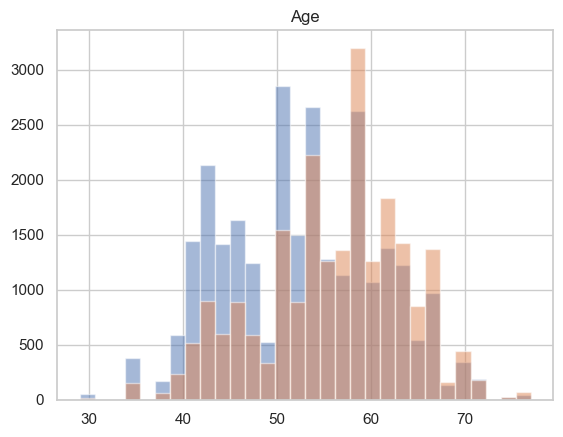

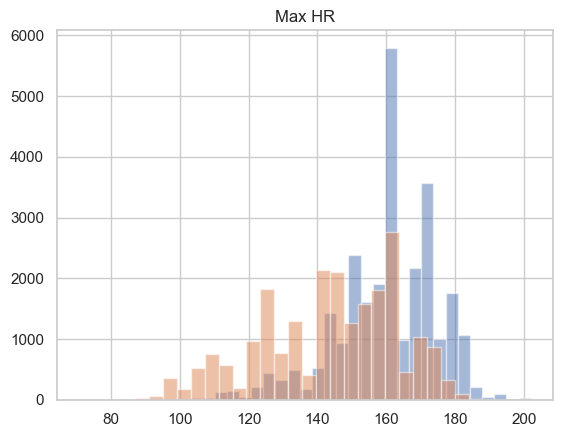

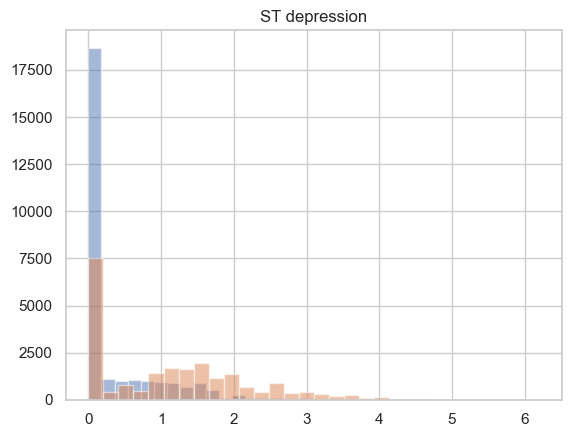

In [13]:
# Numeric: target-wise hist (sampled for speed)
cols = ["Age", "Max HR", "ST depression"]
tmp = train.sample(50_000, random_state=42).assign(y=y)

for c in cols:
    plt.figure()
    tmp[tmp["y"] == 0][c].hist(alpha=0.5, bins=30)
    tmp[tmp["y"] == 1][c].hist(alpha=0.5, bins=30)
    plt.title(c)
    plt.show()


/var/folders/_n/zkwnlxm959j1s3pt15cz_xmw0000gn/T/ipykernel_43036/1538933057.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("x")["y"]


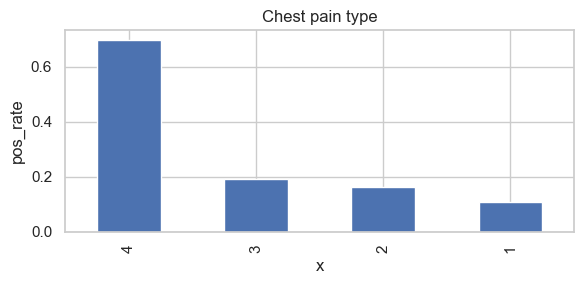

/var/folders/_n/zkwnlxm959j1s3pt15cz_xmw0000gn/T/ipykernel_43036/1538933057.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("x")["y"]


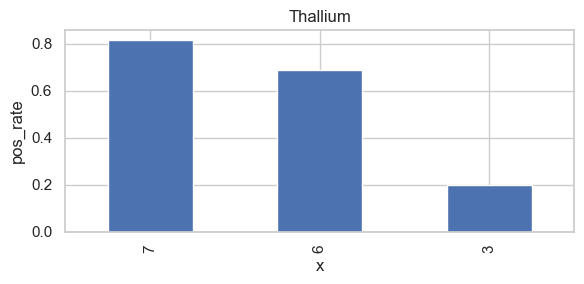

/var/folders/_n/zkwnlxm959j1s3pt15cz_xmw0000gn/T/ipykernel_43036/1538933057.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("x")["y"]


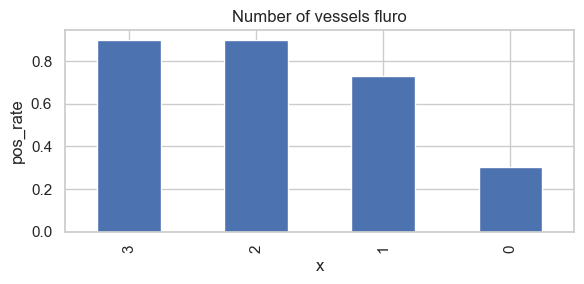

In [14]:
# Categorical: pos_rate by category
cat_plot_cols = ["Chest pain type", "Thallium", "Number of vessels fluro"]

for c in cat_plot_cols:
    if c not in train.columns:
        continue
    df = pos_rate_by_category(c)
    plt.figure(figsize=(6, 3))
    df["pos_rate"].plot(kind="bar")
    plt.title(c)
    plt.ylabel("pos_rate")
    plt.tight_layout()
    plt.show()


### Train vs Test distribution drift

- Continuous: KS statistic / PSI (simple)
- Categorical: rate differences


In [15]:
from scipy.stats import ks_2samp

# PSI (simple)
def psi(expected, actual, buckets=10):
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()
    if expected.nunique() <= 1 or actual.nunique() <= 1:
        return 0.0
    quantiles = np.linspace(0, 1, buckets + 1)
    bins = np.unique(np.quantile(expected, quantiles))
    if len(bins) <= 2:
        return 0.0
    expected_counts = pd.cut(expected, bins=bins, include_lowest=True).value_counts(normalize=True)
    actual_counts = pd.cut(actual, bins=bins, include_lowest=True).value_counts(normalize=True)
    # align
    expected_counts, actual_counts = expected_counts.align(actual_counts, fill_value=1e-6)
    psi_val = np.sum((expected_counts - actual_counts) * np.log(expected_counts / actual_counts))
    return float(psi_val)

num_cols_train = [c for c in num_cols if c in test.columns and c != ID_COL]

rows = []
for c in num_cols_train:
    ks_stat = ks_2samp(train[c].dropna(), test[c].dropna()).statistic
    psi_val = psi(train[c], test[c])
    rows.append((c, ks_stat, psi_val))

drift_num = pd.DataFrame(rows, columns=["col", "ks", "psi"]).sort_values(["psi", "ks"], ascending=False)
drift_num.head(20)


,col,ks,psi
4,ST depression,0.002571,0.000046
0,Age,0.002162,0.000041
3,Max HR,0.001737,0.000038
1,BP,0.002328,0.000037
2,Cholesterol,0.001396,0.000018


### Categorical rate differences

In [16]:
cat_cols = [c for c in FEATURE_COLS if c in test.columns and train[c].nunique(dropna=True) <= 20]

rows = []
for c in cat_cols:
    train_rate = train[c].value_counts(normalize=True)
    test_rate = test[c].value_counts(normalize=True)
    diff = (train_rate - test_rate).abs().fillna(0).sum() / 2
    rows.append((c, diff))

drift_cat = pd.DataFrame(rows, columns=["col", "total_variation_distance"]).sort_values(
    "total_variation_distance", ascending=False
)
drift_cat.head(20)


,col,total_variation_distance
5,Slope of ST,0.003089
6,Number of vessels fluro,0.002210
1,Chest pain type,0.002090
3,EKG results,0.001618
0,Sex,0.001580
4,Exercise angina,0.000930
7,Thallium,0.000311
2,FBS over 120,0.000065


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

model_feature_cols = [c for c in train.columns if c not in [target_col, ID_COL]]

cat_cols_model = [c for c in model_feature_cols if train[c].nunique(dropna=True) <= 20]
num_cols_model = [c for c in model_feature_cols if c not in cat_cols_model]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols_model),
    ("cat", cat_pipe, cat_cols_model),
])

clf = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, solver="lbfgs")),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, train[model_feature_cols], y, cv=cv, scoring="roc_auc")


In [18]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_out = cross_validate(
    clf,
    train[model_feature_cols],
    y,
    cv=cv,
    scoring="roc_auc",
    return_train_score=False,
)

cv_table = pd.DataFrame({
    "fold": range(1, len(cv_out["test_score"]) + 1),
    "roc_auc": cv_out["test_score"],
})
cv_table.loc["mean"] = ["mean", cv_table["roc_auc"].mean()]
cv_table.loc["std"]  = ["std",  cv_table["roc_auc"].std()]
cv_table


,fold,roc_auc
0,1,0.953284
1,2,0.952289
2,3,0.953031
3,4,0.952644
4,5,0.953362
mean,mean,0.952922
std,std,0.000404


### Submit prediction

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

TARGET = target_col  # "Heart Disease"
ID_COL = "id"

X_train = train.drop(columns=[TARGET])
X_test  = test.copy()

# Treat low-cardinality cols as categorical
feature_cols = [c for c in X_train.columns if c != ID_COL]
cat_cols = [c for c in feature_cols if train[c].nunique() <= 20]
num_cols = [c for c in feature_cols if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop",
)

clf_lr = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, n_jobs=-1)),
    ]
)

clf_lr.fit(X_train[feature_cols], y)

# Kaggle binary classification usually requires probability of positive class
test_pred = clf_lr.predict_proba(X_test[feature_cols])[:, 1]

submit = sub.copy()
submit["Heart Disease"] = test_pred
submit.to_csv("../data/submissions/lr_baseline.csv", index=False)

submit.head()


,id,Heart Disease
0,630000,0.892123
1,630001,0.004949
2,630002,0.989946
3,630003,0.005177
4,630004,0.270936
